In [4]:
from matplotlib import pyplot as plt
from jax import numpy as jnp
# Plot-Formatierung
plt.rcParams['font.size'] = 24.0
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelsize'] = 'medium'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['lines.linewidth'] = 2.0


In [5]:
def params(mean, std):
    mu = jnp.log(mean)-0.5*jnp.log((std/mean)**2+1)
    sigma = jnp.sqrt(jnp.log((std/mean)**2+1))
    return mu, sigma

def lognorm(x, mu, sigma):
    return 1/(x*sigma*jnp.sqrt(2*jnp.pi))*jnp.exp(-0.5*((jnp.log(x)-mu)/sigma)**2)

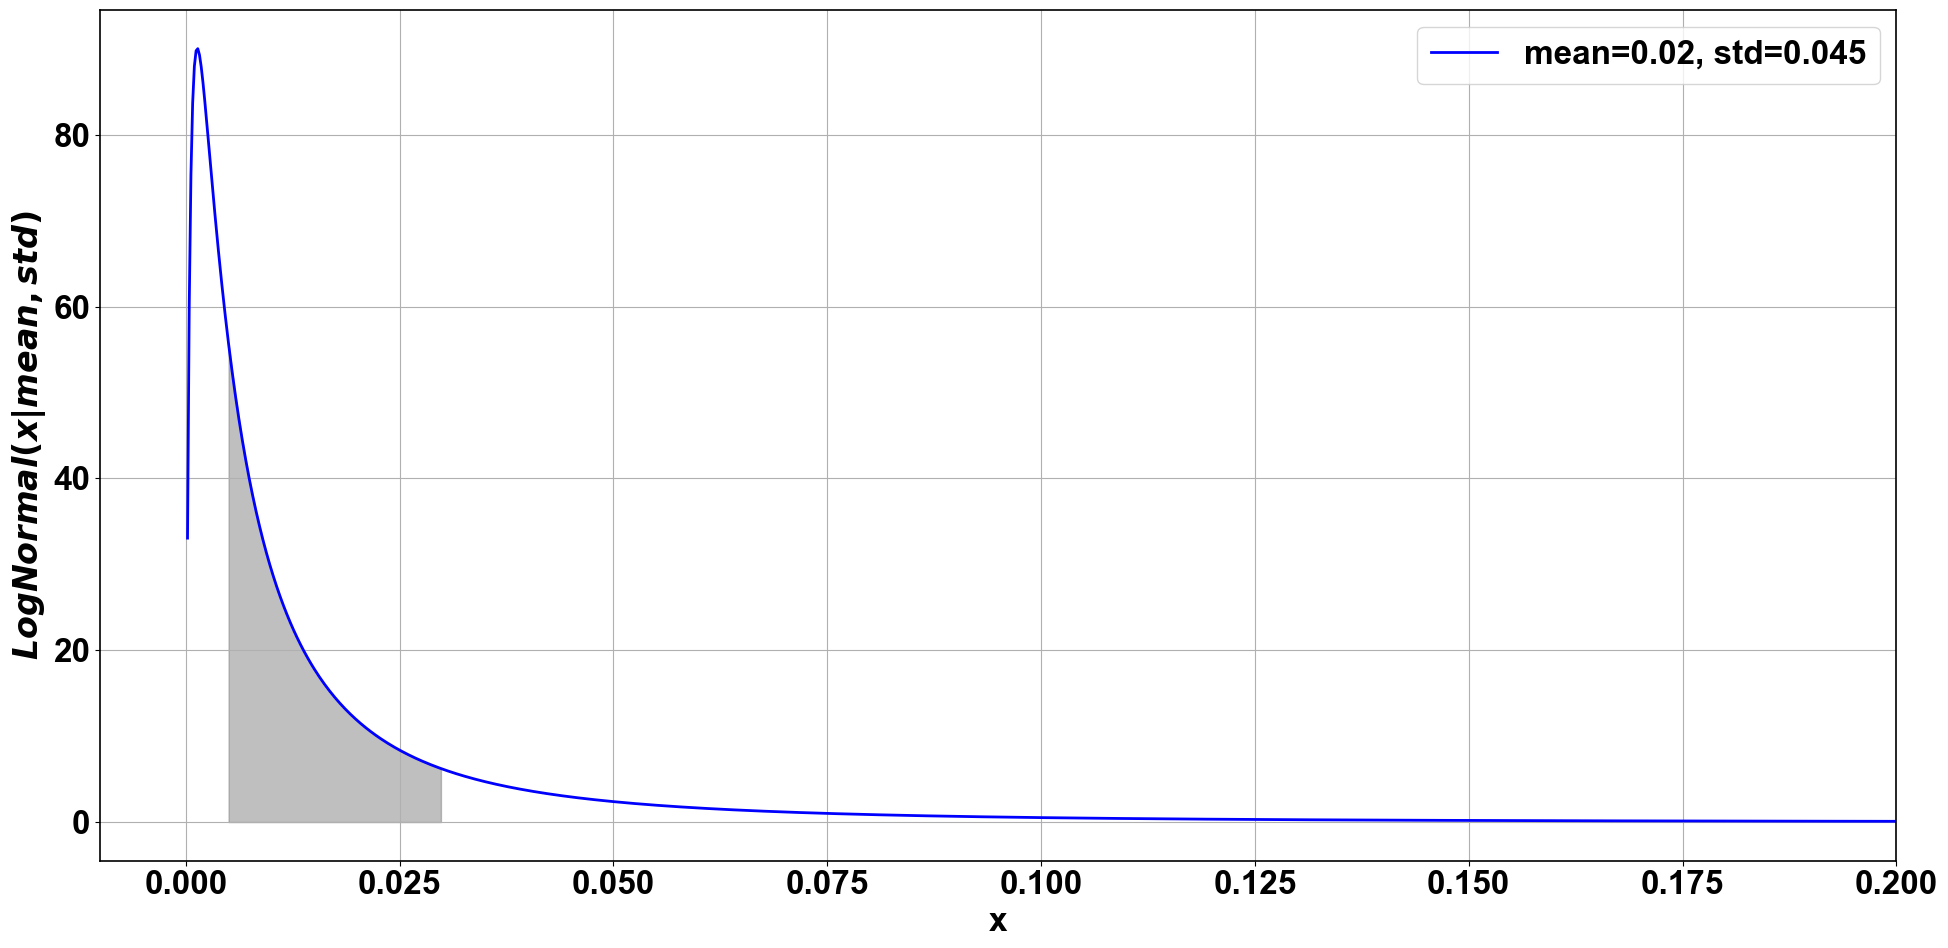

In [36]:
mean = 0.02
std = 0.015 * 3
fig, ax = plt.subplots(figsize=(20,10))
x = jnp.linspace(0, 0.2, 1000)
y = lognorm(x, *params(mean, std))
ax.set_xlabel('x')
ax.set_xlim(-0.01, 0.2)
ax.set_ylabel('$LogNormal(x|mean, std)$')
ax.plot(x, y, label=f'mean={mean}, std={std}', color='blue') 
ax.fill_between(x, y, where=(x >= 0.005) & (x <= 0.03), color='gray', alpha=0.5)
ax.grid()
ax.legend()
fig.tight_layout()